## Kimi

Loaded noise types: Dropout, Gaussian, Poisson


MERG NOT subset; don't know how to subset; dropped
MERG NOT subset; don't know how to subset; dropped


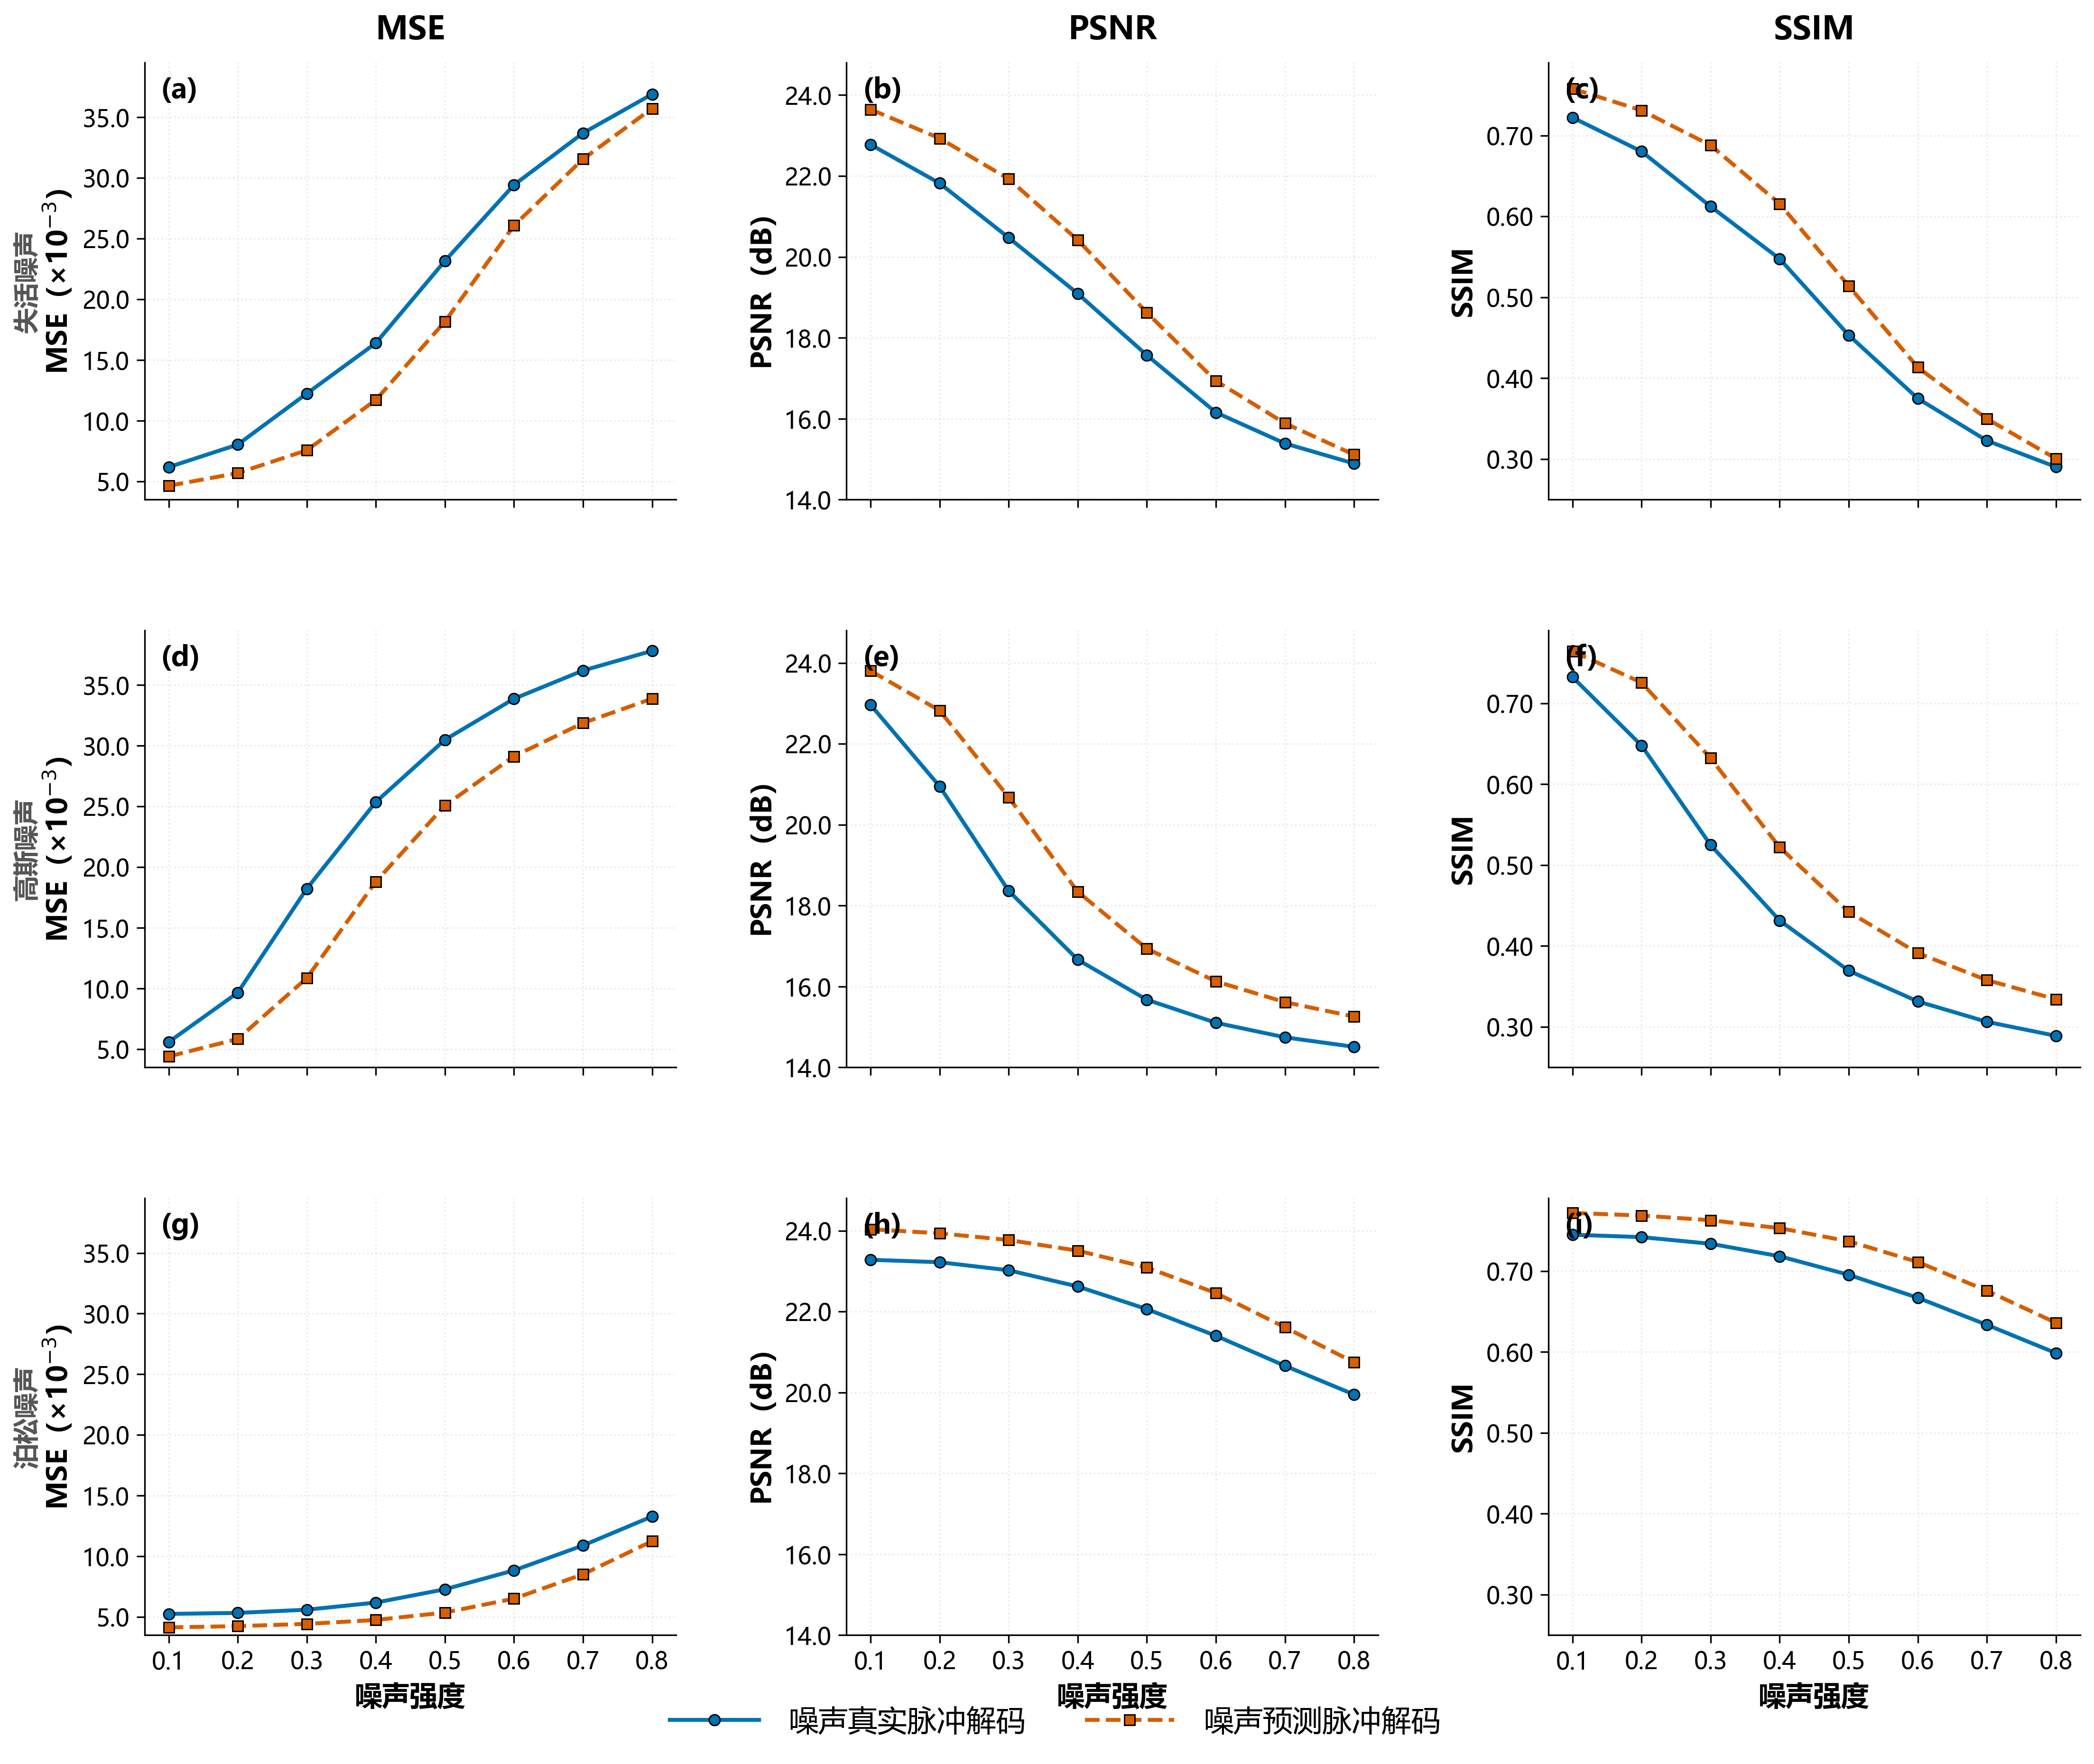

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec

# ============================================================
# 本地字体设置（你的电脑支持这些字体）
# ============================================================
# 明确设置字体家族为sans-serif，并配置中文字体优先级
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42  # 允许字体嵌入

# 字号全面调大
plt.rcParams.update({
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# ============================================================
# 你的原始数据加载代码（保持不变）
# ============================================================
from pathlib import Path
import json
# 
base_dir = Path(r'g:\L\noisy_spike_decode\results')
noise_sources = {
     'Dropout': base_dir / 'dropout' / 'allensdk_22' / 'movie1' / 'summary_plots' / 'aggregated_metrics.json',
     'Gaussian': base_dir / 'gaussian' / 'allensdk_22' / 'movie1' / 'summary_plots_gaussian' / 'aggregated_metrics.json',
     'Poisson': base_dir / 'poisson' / 'allensdk_22' / 'movie1' / 'summary_plots_poisson' / 'aggregated_metrics.json',
 }
 
def load_aggregated_metrics(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        raw = json.load(f)

    noise_levels = []
    noisy_spike = {'mse': [], 'psnr': [], 'ssim': []}
    noisy_pred = {'mse': [], 'psnr': [], 'ssim': []}

    for key in sorted(raw.keys(), key=lambda x: float(x)):
        entry = raw[key]
        if 'noisy_spike_decode' not in entry:
            continue
        noise_levels.append(float(key))
        for metric in ['mse', 'psnr', 'ssim']:
            noisy_spike[metric].append(float(entry['noisy_spike_decode'][metric]))
            noisy_pred[metric].append(float(entry['noisy_pred_spike_decode'][metric]))

    return {
        'noise_levels': np.array(noise_levels, dtype=float),
        'noisy_spike_decode': {k: np.array(v, dtype=float) for k, v in noisy_spike.items()},
        'noisy_pred_spike_decode': {k: np.array(v, dtype=float) for k, v in noisy_pred.items()},
    }

all_data = {noise_name: load_aggregated_metrics(path) for noise_name, path in noise_sources.items()}
print('Loaded noise types:', ', '.join(all_data.keys()))

# ============================================================
# 配置参数（中文标签）
# ============================================================
row_labels = {
    'Dropout': '失活噪声',
    'Gaussian': '高斯噪声',
    'Poisson': '泊松噪声',
}

metric_configs = {
    'mse': {
        'title': 'MSE',
        'ylabel': 'MSE（×10$^{-3}$）',
        'formatter': FuncFormatter(lambda v, p: f'{v * 1e3:.1f}'),
    },
    'psnr': {
        'title': 'PSNR',
        'ylabel': 'PSNR（dB）',
        'formatter': FuncFormatter(lambda v, p: f'{v:.1f}'),
    },
    'ssim': {
        'title': 'SSIM',
        'ylabel': 'SSIM',
        'formatter': FuncFormatter(lambda v, p: f'{v:.2f}'),
    },
}

series_labels = {
    'noisy_spike_decode': '噪声真实脉冲解码',
    'noisy_pred_spike_decode': '噪声预测脉冲解码',
}

# 柔和学术配色（色盲友好）
line_styles = {
    'noisy_spike_decode': {
        'color': '#0072B2',  # 蓝色
        'marker': 'o',
        'linestyle': '-',
        'linewidth': 2.0,
        'markersize': 5.5,
        'markerfacecolor': '#0072B2',
        'markeredgecolor': 'black',
        'markeredgewidth': 0.7,
    },
    'noisy_pred_spike_decode': {
        'color': '#D55E00',  # 橙色
        'marker': 's',
        'linestyle': '--',
        'linewidth': 2.0,
        'markersize': 5.5,
        'markerfacecolor': '#D55E00',
        'markeredgecolor': 'black',
        'markeredgewidth': 0.7,
    },
}

panel_labels = list('abcdefghi')

# ============================================================
# 创建 3×3 布局（增大尺寸）
# ============================================================
fig = plt.figure(figsize=(16, 13), dpi=300)
gs = GridSpec(3, 3, figure=fig, 
              left=0.10, right=0.95, top=0.93, bottom=0.08,
              wspace=0.32, hspace=0.30)

metric_order = ['mse', 'psnr', 'ssim']
noise_order = ['Dropout', 'Gaussian', 'Poisson']
metric_ylim = {
    'mse': (0.0035, 0.0395),
    'psnr': (14.0, 24.8),
    'ssim': (0.25, 0.79),
}

first_handles = None
x_ticks = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
x_tick_labels = [f'{x:.1f}' for x in x_ticks]
panel_index = 0

for row_idx, noise_name in enumerate(noise_order):
    data = all_data[noise_name]  # 替换为你的真实数据
    noise_levels = data['noise_levels']

    for col_idx, metric in enumerate(metric_order):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        y_true = data['noisy_spike_decode'][metric]
        y_pred = data['noisy_pred_spike_decode'][metric]

        # 绘制真实脉冲解码
        ax.plot(noise_levels, y_true, 
                marker=line_styles['noisy_spike_decode']['marker'],
                linestyle=line_styles['noisy_spike_decode']['linestyle'],
                color=line_styles['noisy_spike_decode']['color'],
                linewidth=line_styles['noisy_spike_decode']['linewidth'],
                markersize=line_styles['noisy_spike_decode']['markersize'],
                markerfacecolor=line_styles['noisy_spike_decode']['markerfacecolor'],
                markeredgecolor=line_styles['noisy_spike_decode']['markeredgecolor'],
                markeredgewidth=line_styles['noisy_spike_decode']['markeredgewidth'],
                label=series_labels['noisy_spike_decode'],
                zorder=3)
        
        # 绘制CNN预测解码
        ax.plot(noise_levels, y_pred,
                marker=line_styles['noisy_pred_spike_decode']['marker'],
                linestyle=line_styles['noisy_pred_spike_decode']['linestyle'],
                color=line_styles['noisy_pred_spike_decode']['color'],
                linewidth=line_styles['noisy_pred_spike_decode']['linewidth'],
                markersize=line_styles['noisy_pred_spike_decode']['markersize'],
                markerfacecolor=line_styles['noisy_pred_spike_decode']['markerfacecolor'],
                markeredgecolor=line_styles['noisy_pred_spike_decode']['markeredgecolor'],
                markeredgewidth=line_styles['noisy_pred_spike_decode']['markeredgewidth'],
                label=series_labels['noisy_pred_spike_decode'],
                zorder=3)

        ax.set_ylim(*metric_ylim[metric])
        ax.grid(True, linestyle=':', alpha=0.4, color='#CCCCCC')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=12, direction='out')
        ax.yaxis.set_major_formatter(metric_configs[metric]['formatter'])

        # 列标题（只在第一行显示）
        if row_idx == 0:
            ax.set_title(metric_configs[metric]['title'], fontsize=16, 
                        fontweight='bold', pad=12)

        # y轴标签
        ax.set_ylabel(metric_configs[metric]['ylabel'], fontsize=14, 
                     fontweight='bold', fontfamily='sans-serif')

        # x轴标签（只在最后一行显示）
        if row_idx == 2:
            ax.set_xlabel('噪声强度', fontsize=14, fontweight='bold', fontfamily='sans-serif')
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_tick_labels, fontsize=12)
        else:
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([])

        # 行标签（只在第一列显示）
        if col_idx == 0:
            ax.text(-0.22, 0.5, row_labels[noise_name], transform=ax.transAxes,
                    rotation=90, va='center', ha='center', fontsize=13, 
                    fontweight='bold', color='#555555', fontfamily='sans-serif')

        # 子图标签
        ax.text(0.03, 0.97, f'({panel_labels[panel_index]})', 
                transform=ax.transAxes, fontsize=14, fontweight='bold', 
                va='top', color='black')
        panel_index += 1

        if first_handles is None:
            first_handles, _ = ax.get_legend_handles_labels()

# 图例放在图外底部中央
fig.legend(first_handles, 
           [series_labels['noisy_spike_decode'], series_labels['noisy_pred_spike_decode']],
           loc='lower center', ncol=2, frameon=False, 
           bbox_to_anchor=(0.5, 0.01), fontsize=15,
           handlelength=3, handletextpad=1)

# ============================================================
# 保存
# ============================================================
plt.savefig('noise_summary_figure_chinese_large.pdf', 
            dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('noise_summary_figure_chinese_large.png', 
            dpi=300, bbox_inches='tight', format='png')
plt.show() 

## Claude

Loaded noise types: Dropout, Gaussian, Poisson


MERG NOT subset; don't know how to subset; dropped
MERG NOT subset; don't know how to subset; dropped


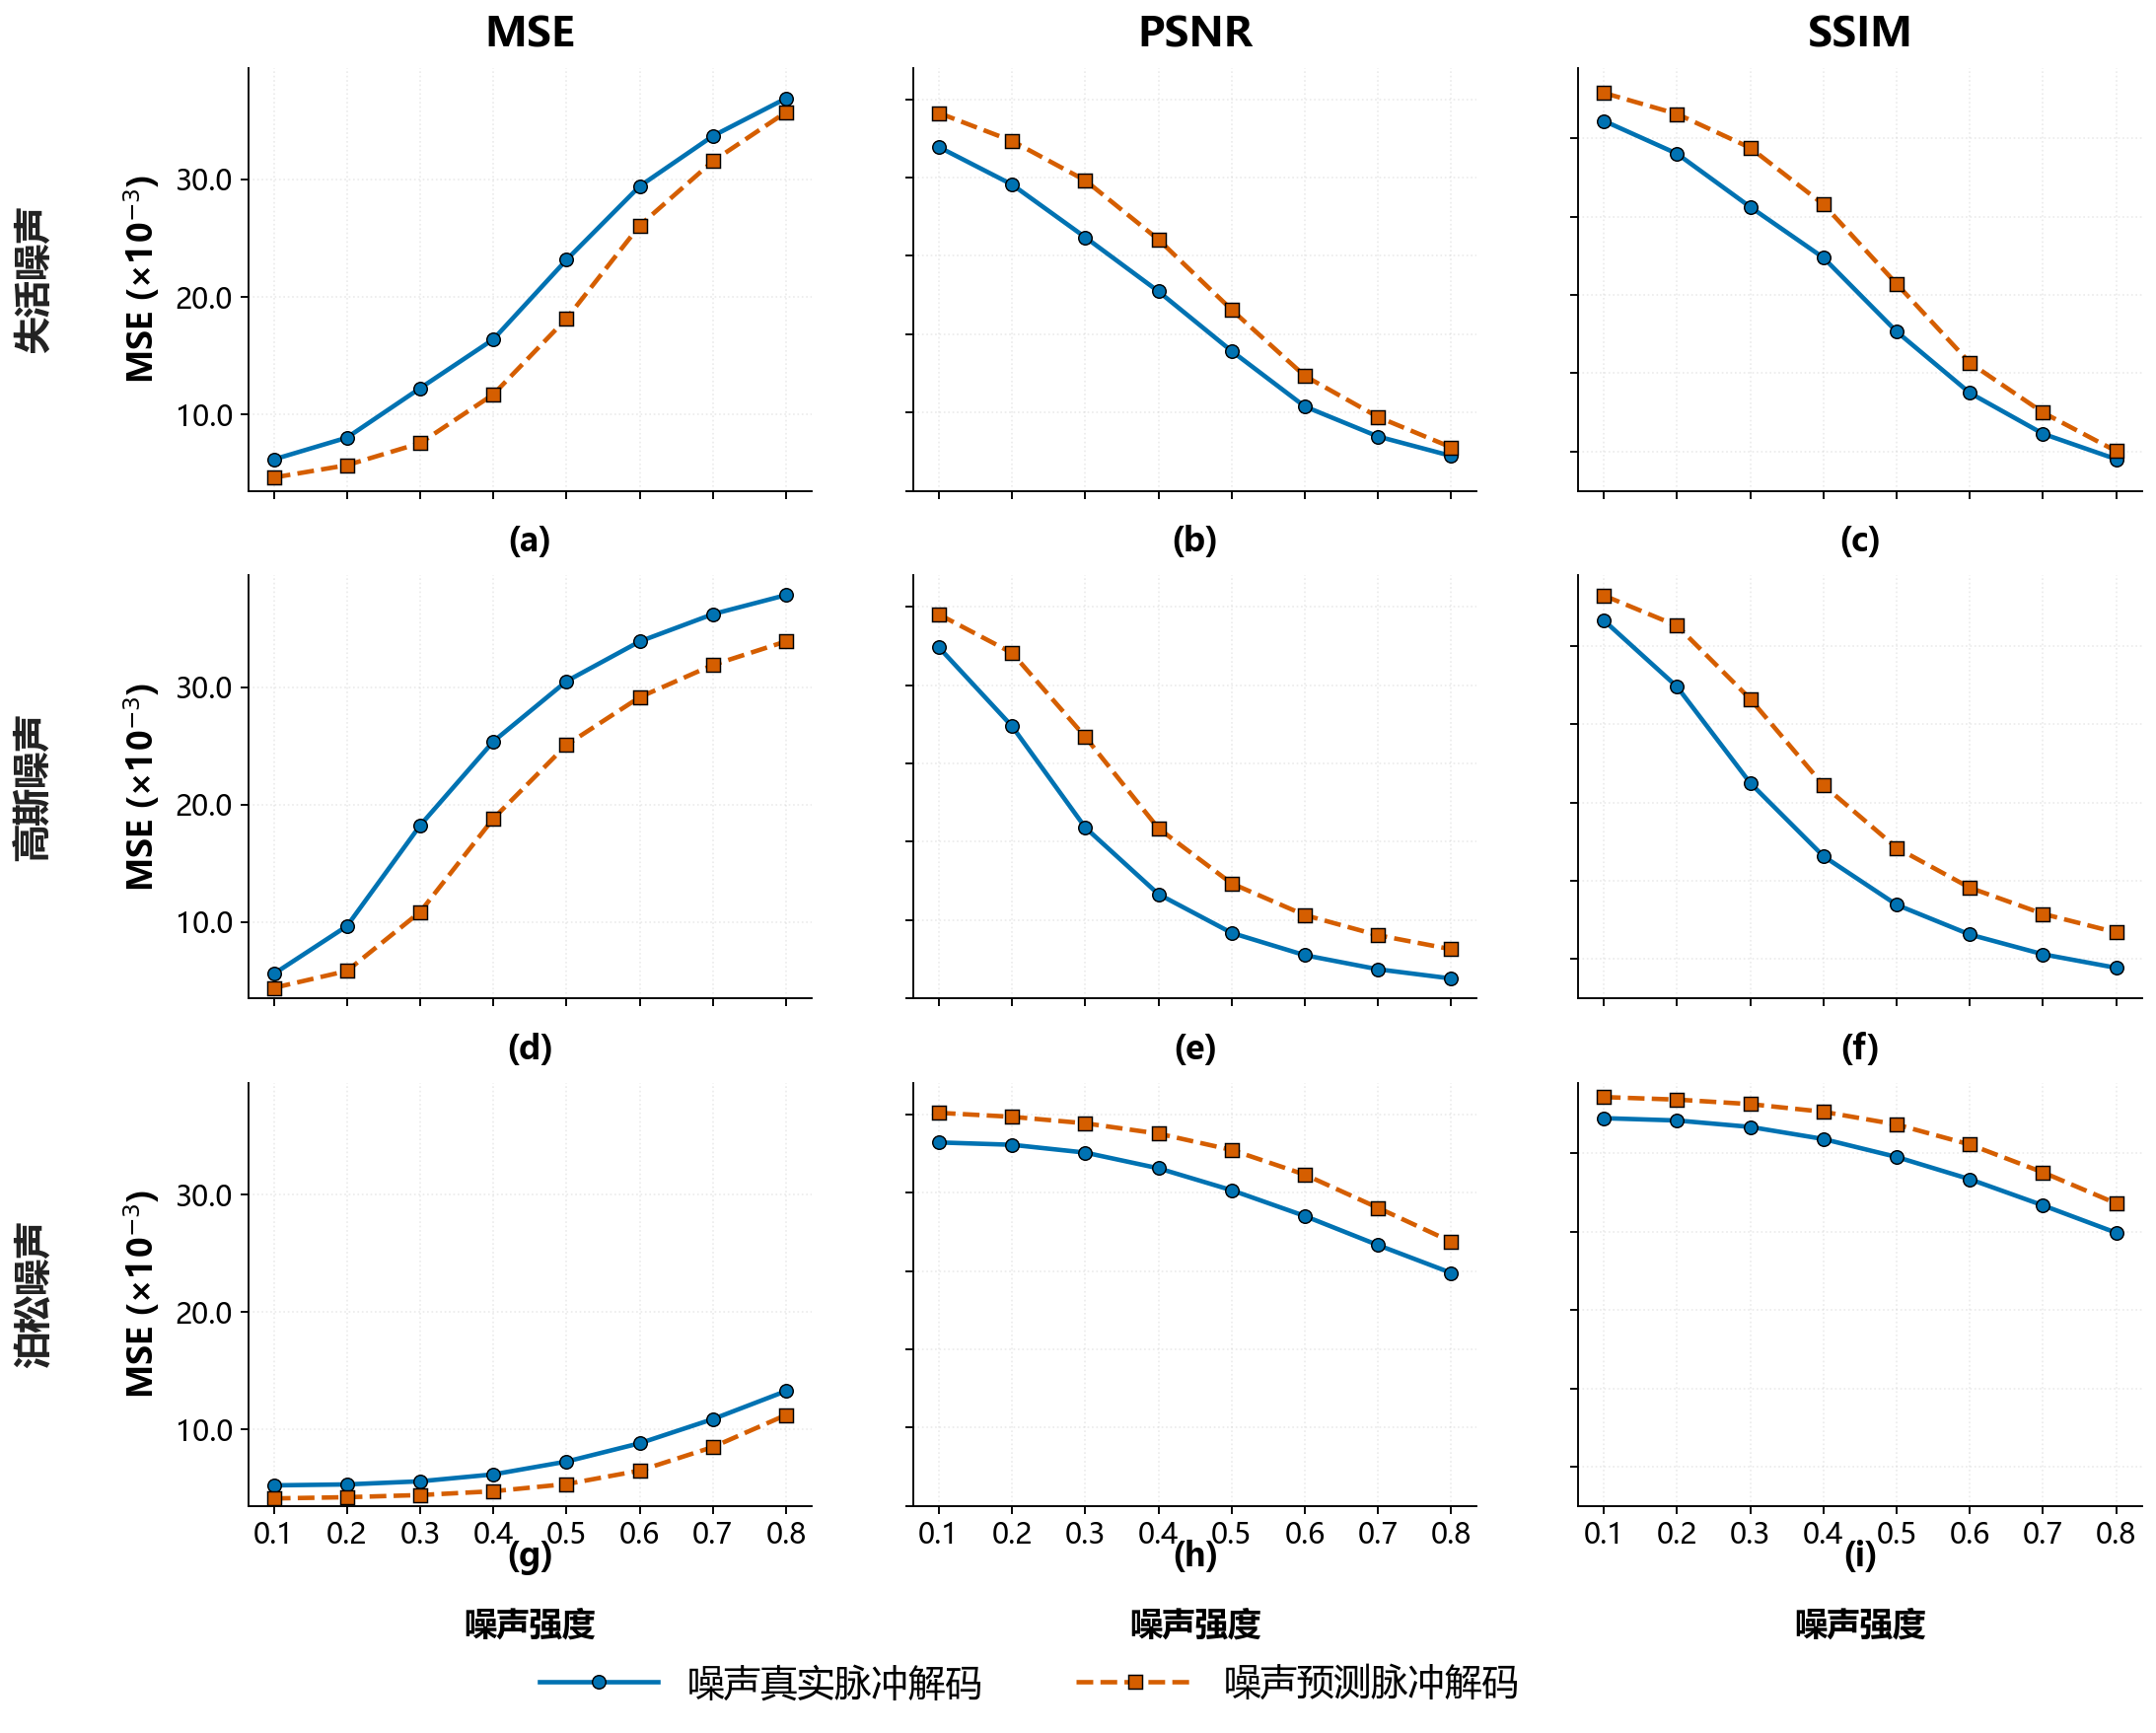

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec

# ============================================================
# 字体设置
# ============================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({
    'axes.linewidth': 0.9,
    'xtick.major.width': 0.9, 'ytick.major.width': 0.9,
    'xtick.major.size': 4,    'ytick.major.size': 4,
})

# ============================================================
# 模拟数据（本地替换为真实 load_aggregated_metrics 逻辑）
# ============================================================
noise_levels = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

from pathlib import Path
import json
# 
base_dir = Path(r'g:\L\noisy_spike_decode\results')
noise_sources = {
     'Dropout': base_dir / 'dropout' / 'allensdk_22' / 'movie1' / 'summary_plots' / 'aggregated_metrics.json',
     'Gaussian': base_dir / 'gaussian' / 'allensdk_22' / 'movie1' / 'summary_plots_gaussian' / 'aggregated_metrics.json',
     'Poisson': base_dir / 'poisson' / 'allensdk_22' / 'movie1' / 'summary_plots_poisson' / 'aggregated_metrics.json',
 }
 
def load_aggregated_metrics(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        raw = json.load(f)

    noise_levels = []
    noisy_spike = {'mse': [], 'psnr': [], 'ssim': []}
    noisy_pred = {'mse': [], 'psnr': [], 'ssim': []}

    for key in sorted(raw.keys(), key=lambda x: float(x)):
        entry = raw[key]
        if 'noisy_spike_decode' not in entry:
            continue
        noise_levels.append(float(key))
        for metric in ['mse', 'psnr', 'ssim']:
            noisy_spike[metric].append(float(entry['noisy_spike_decode'][metric]))
            noisy_pred[metric].append(float(entry['noisy_pred_spike_decode'][metric]))

    return {
        'noise_levels': np.array(noise_levels, dtype=float),
        'noisy_spike_decode': {k: np.array(v, dtype=float) for k, v in noisy_spike.items()},
        'noisy_pred_spike_decode': {k: np.array(v, dtype=float) for k, v in noisy_pred.items()},
    }

all_data = {noise_name: load_aggregated_metrics(path) for noise_name, path in noise_sources.items()}
print('Loaded noise types:', ', '.join(all_data.keys()))

# ============================================================
# 字号
# ============================================================
FS_COL_TITLE  = 20
FS_ROW_LABEL  = 18
FS_AXIS_LABEL = 16
FS_TICK       = 14
FS_PANEL      = 16
FS_LEGEND     = 18

# ============================================================
# 配置
# ============================================================
row_labels = {'Dropout': '失活噪声', 'Gaussian': '高斯噪声', 'Poisson': '泊松噪声'}

metric_configs = {
    'mse':  {'title': 'MSE',  'ylabel': 'MSE (×10$^{-3}$)',
              'formatter': FuncFormatter(lambda v, p: f'{v*1e3:.1f}')},
    'psnr': {'title': 'PSNR', 'ylabel': 'PSNR (dB)',
              'formatter': FuncFormatter(lambda v, p: f'{v:.1f}')},
    'ssim': {'title': 'SSIM', 'ylabel': 'SSIM',
              'formatter': FuncFormatter(lambda v, p: f'{v:.2f}')},
}

series_labels = {
    'noisy_spike_decode':      '噪声真实脉冲解码',
    'noisy_pred_spike_decode': '噪声预测脉冲解码',
}

line_styles = {
    'noisy_spike_decode': {
        'color': '#0072B2', 'marker': 'o', 'linestyle': '-',
        'linewidth': 2.2, 'markersize': 6.5,
        'markerfacecolor': '#0072B2', 'markeredgecolor': 'black', 'markeredgewidth': 0.7,
    },
    'noisy_pred_spike_decode': {
        'color': '#D55E00', 'marker': 's', 'linestyle': '--',
        'linewidth': 2.2, 'markersize': 6.5,
        'markerfacecolor': '#D55E00', 'markeredgecolor': 'black', 'markeredgewidth': 0.7,
    },
}

metric_ylim = {'mse': (0.0035, 0.0395), 'psnr': (14.0, 24.8), 'ssim': (0.25, 0.79)}
noise_order  = ['Dropout', 'Gaussian', 'Poisson']
metric_order = ['mse', 'psnr', 'ssim']
panel_labels = list('abcdefghi')
x_ticks      = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

# ============================================================
# 布局
#   left=0.17  → 给 y轴刻度 + y轴标签 + 行标签三层留足空间
#   bottom=0.12 → 给 x刻度 + "噪声强度" + 子图编号 + 图例四层留足空间
#   wspace=0.18 → 列间紧凑（只有刻度数字，无重复y轴标签）
#   hspace=0.20 → 行间紧凑
# ============================================================
fig = plt.figure(figsize=(16, 12), dpi=150)
gs = GridSpec(3, 3, figure=fig,
              left=0.17,    # ← 加宽，给行标签 + y轴标签各自留空间
              right=0.97,
              top=0.94,
              bottom=0.13,  # ← 加高，给子图编号 + x轴标签 + 图例留空间
              wspace=0.18,  # ← 列间收紧（无重复y轴标签后可以更紧）
              hspace=0.20)

first_handles = None
panel_index   = 0

for row_idx, noise_name in enumerate(noise_order):
    data = all_data[noise_name]

    for col_idx, metric in enumerate(metric_order):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        y_true = data['noisy_spike_decode'][metric]
        y_pred = data['noisy_pred_spike_decode'][metric]

        for key, y in [('noisy_spike_decode', y_true), ('noisy_pred_spike_decode', y_pred)]:
            ls = line_styles[key]
            ax.plot(noise_levels, y,
                    marker=ls['marker'], linestyle=ls['linestyle'],
                    color=ls['color'], linewidth=ls['linewidth'],
                    markersize=ls['markersize'],
                    markerfacecolor=ls['markerfacecolor'],
                    markeredgecolor=ls['markeredgecolor'],
                    markeredgewidth=ls['markeredgewidth'],
                    label=series_labels[key], zorder=3)

        ax.set_ylim(*metric_ylim[metric])
        ax.yaxis.set_major_formatter(metric_configs[metric]['formatter'])
        ax.grid(True, linestyle=':', alpha=0.4, color='#CCCCCC')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=FS_TICK, direction='out')

        # ── 列标题：仅第一行 ──
        if row_idx == 0:
            ax.set_title(metric_configs[metric]['title'],
                         fontsize=FS_COL_TITLE, fontweight='bold', pad=10)

        # ── y 轴标签：仅第一列；其余列只保留刻度数字 ──
        if col_idx == 0:
            ax.set_ylabel(metric_configs[metric]['ylabel'],
                          fontsize=FS_AXIS_LABEL, fontweight='bold', labelpad=6)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        # ── x 轴刻度：仅最后一行显示数字和"噪声强度" ──
        ax.set_xticks(x_ticks)
        if row_idx == 2:
            ax.set_xticklabels([f'{x:.1f}' for x in x_ticks], fontsize=FS_TICK)
            # "噪声强度" labelpad 加大，与子图编号之间留出安全距离
            ax.set_xlabel('噪声强度', fontsize=FS_AXIS_LABEL, fontweight='bold', labelpad=28)
        else:
            ax.set_xticklabels([])

        # ── 行标签：竖排，放在 y轴标签 更左侧，两者不重叠 ──
        # -0.38 在 axes 坐标下足够推到 y轴标签左边
        if col_idx == 0:
            ax.text(-0.38, 0.5, row_labels[noise_name],
                    transform=ax.transAxes,
                    rotation=90, va='center', ha='center',
                    fontsize=FS_ROW_LABEL, fontweight='bold', color='#222222')

        # ── 子图编号：x轴正下方居中，固定 axes 坐标 -0.08
        #    最后一行偏移更大（-0.08）以跳过 x刻度数字；
        #    "噪声强度" 用 labelpad=28 推到编号下方，两者不重叠
        panel_offset = -0.08   # 对所有行统一，跳过 x 刻度层
        ax.text(0.5, panel_offset,
                f'({panel_labels[panel_index]})',
                transform=ax.transAxes,
                fontsize=FS_PANEL, fontweight='bold',
                va='top', ha='center', color='black')
        panel_index += 1

        if first_handles is None:
            first_handles, _ = ax.get_legend_handles_labels()

# ============================================================
# 图例：图正下方
# ============================================================
fig.legend(
    first_handles,
    [series_labels['noisy_spike_decode'], series_labels['noisy_pred_spike_decode']],
    loc='lower center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.0),
    fontsize=FS_LEGEND,
    handlelength=3.2,
    handletextpad=0.8,
    columnspacing=2.5,
)


plt.savefig('noise_summary_figure_chinese_large.pdf', 
            dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('noise_summary_figure_chinese_large.png', 
            dpi=300, bbox_inches='tight', format='png')
plt.show() 
